## Demo: Difussion processes with MINST

Author: alberto.suarez@uam.es
Date: 2025-03-02

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np

from functools import partial 

import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

import torch
from torch.utils.data import (
    DataLoader,
    Dataset,
    Subset,
)
from torchvision import datasets
from torchvision.transforms import ToTensor
from torchvision.transforms import functional

import diffusion_process as dfp

from diffusion_utilities import (
    plot_image_grid,
    plot_image_evolution,
    animation_images,
)

n_threads = torch.get_num_threads()
print('Number of threads: {:d}'.format(n_threads))

_ = torch.manual_seed(123) # For reproducibility

Number of threads: 4


In [2]:
# Dataset MINST
data_train = datasets.MNIST(
    root='data',
    train=True,
    download=True,
    transform=ToTensor()
)
print(type(data_train))


<class 'torchvision.datasets.mnist.MNIST'>


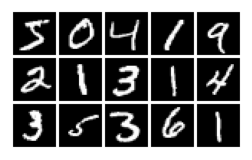

In [3]:
# Visualize MNIST images
n_rows = 3 
n_cols = 5

_ = plot_image_grid(
    images=[data_train[i][0] for i in range(n_rows * n_cols)],
    figsize =(3, 3),
    n_rows=n_rows, 
    n_cols=n_cols,
)



In [4]:
# Create a DataLoader
batch_size = 64
data_train_loader = DataLoader(
    data_train, 
    batch_size=batch_size, 
    shuffle=True, 
    num_workers=n_threads
)
print(type(data_train_loader))

images_0, labels = next(iter(data_train_loader))  # Get first batch
print(type(images_0))
print(images_0.shape)

<class 'torch.utils.data.dataloader.DataLoader'>
<class 'torch.Tensor'>
torch.Size([64, 1, 28, 28])


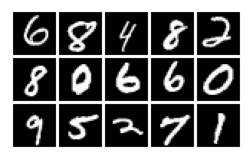

In [5]:
_ = plot_image_grid(
    images=[images_0[i] for i in range(n_rows * n_cols)],
    figsize=(3, 3),
    n_rows=n_rows, 
    n_cols=n_cols,
)

### Forward diffusion (noise injection)

In [6]:
decay_rate = 0.02
def ou_drift_coefficient(x_t, t, decay_rate):
    return - decay_rate * x_t

sigma = 0.05
def ou_diffusion_coefficient(t, sigma):
    return sigma * torch.ones_like(t)

t_0 = 0.0
t_end = 2.0 / decay_rate
n_steps = 501
times, images_t = dfp.euler_maruyama_integrator(
    images_0, 
    t_0,
    t_end, 
    n_steps,
    drift_coefficient=partial(ou_drift_coefficient, decay_rate=decay_rate), 
    diffusion_coefficient=partial(ou_diffusion_coefficient, sigma=sigma),
)
print(type(images_0))
print(images_0.shape)

print(type(images_t))
print(images_t.shape)

<class 'torch.Tensor'>
torch.Size([64, 1, 28, 28])
<class 'torch.Tensor'>
torch.Size([64, 1, 28, 28, 502])


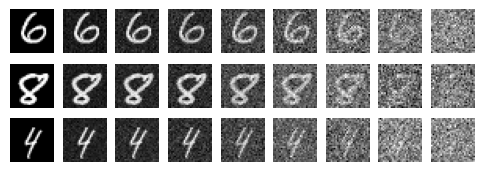

In [7]:
_ = plot_image_evolution(
    images=images_t,
    n_images=3,
    n_intermediate_steps=[0, 5, 10, 20, 50, 100, 200, 300, n_steps - 1],
    figsize=(6, 2),
)

In [8]:
# Animation
n_image = 0
fig, ax, anim = animation_images(
    images_t[n_image, 0], 
    interval=20,
    figsize=(2, 2),
)
plt.close()
HTML(anim.to_jshtml(default_mode='once'))

In [9]:
# Diffusion model

# [TO DO: Complete code]

sigma = 25.0

def bm_drift_coefficient(x_t, t):
    [TO DO: Complete code] 
    
def bm_diffusion_coefficient(t, sigma):
    [TO DO: Complete code]
    
def bm_mu_t(x_0, t):
    [TO DO: Complete code]
    
def bm_sigma_t(t, sigma):
    [TO DO: Complete code]
    
[TO DO: Complete code]

diffusion_process = dfp.GaussianDiffussionProcess(
    drift_coefficient,
    diffusion_coefficient,
    mu_t,
    sigma_t,
)

# Simple score model

def score_model(x_t, t):
    return x_t

# Check score model

diffusion_process.loss_function(
    score_model,
    x_0=images_0,
) 
# Expected output = tensor(981662.5000)  
# It may be different with different versions of the packages


tensor(981662.5000)